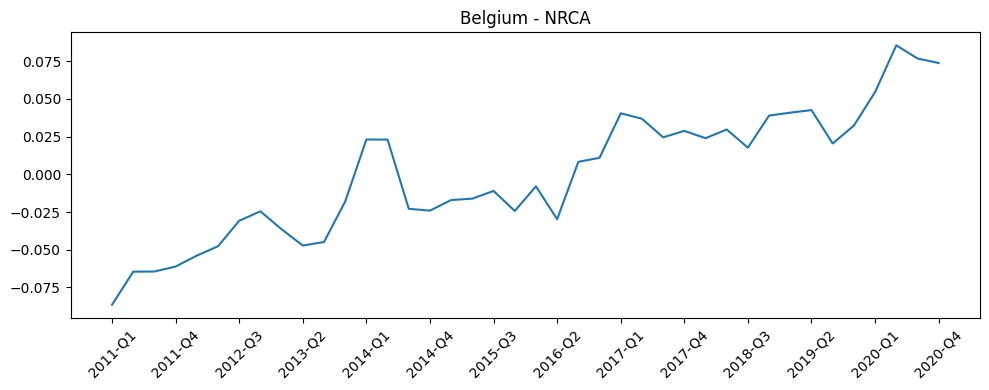

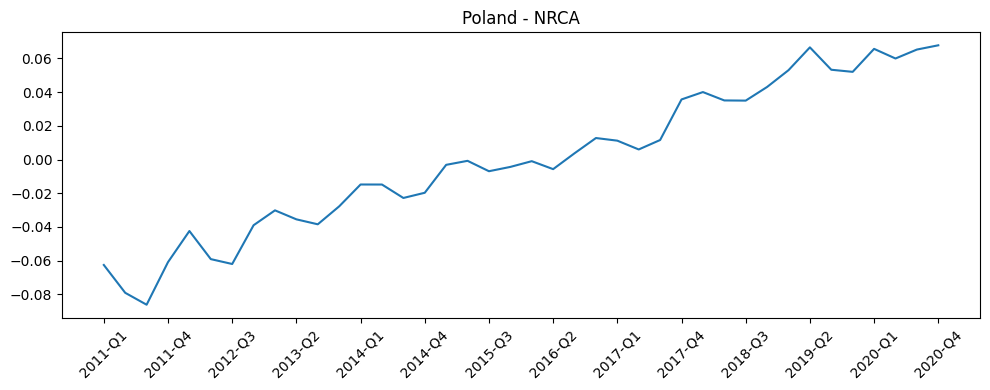

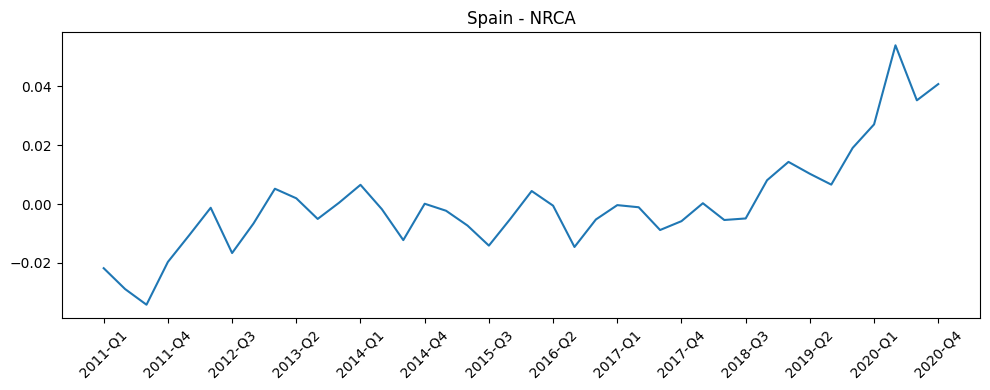

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# Configuration
# ---------------------------
BASE_DIR = Path("/Users/ola/Desktop/studia/magisterka-uw/4-semestr/reproducible-research/RR_git3/repositories/RRcourse2026")
DATA_DIR = BASE_DIR / "Data"

COUNTRIES = ["Belgium", "Poland", "Spain"]
ISCO_LEVELS = range(1, 10)

NRCA_TASKS = [
    "t_4A2a4",  # Analyzing Data or Information
    "t_4A2b2",  # Thinking Creatively
    "t_4A4a1",  # Interpreting the Meaning of Information for Others
]

# ---------------------------
# Helper functions
# ---------------------------
def weighted_zscore(values, weights):
    """Return weighted z-score of a pandas Series."""
    weighted_mean = np.average(values, weights=weights)
    weighted_sd = np.sqrt(np.average((values - weighted_mean) ** 2, weights=weights))
    return (values - weighted_mean) / weighted_sd


def load_isco_data(file_path, sheet_numbers):
    """Load all ISCO sheets and combine them into one DataFrame."""
    frames = []
    for i in sheet_numbers:
        df = pd.read_excel(file_path, sheet_name=f"ISCO{i}")
        df["ISCO"] = i
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


def add_country_totals_and_shares(df, countries):
    """Add total employment and occupation shares for each country."""
    result = df.copy()

    for country in countries:
        total_by_time = result.groupby("TIME")[country].transform("sum")
        result[f"total_{country}"] = total_by_time
        result[f"share_{country}"] = result[country] / result[f"total_{country}"]

    return result


def prepare_task_data(task_data):
    """Aggregate task data to 1-digit ISCO level."""
    task_data = task_data.copy()
    task_data["isco08_1dig"] = task_data["isco08"].astype(str).str[:1].astype(int)

    aggdata = task_data.groupby("isco08_1dig").mean(numeric_only=True).reset_index()

    if "isco08" in aggdata.columns:
        aggdata = aggdata.drop(columns=["isco08"])

    return aggdata


def standardize_tasks_by_country(df, countries, task_vars):
    """Create weighted standardized task columns for each country and task."""
    result = df.copy()

    for country in countries:
        weights = result[f"share_{country}"]

        for task in task_vars:
            result[f"std_{country}_{task}"] = weighted_zscore(result[task], weights)

    return result


def compute_country_index(df, countries, task_vars, index_name="NRCA"):
    """Sum standardized task measures into an index and standardize it again."""
    result = df.copy()

    for country in countries:
        std_task_cols = [f"std_{country}_{task}" for task in task_vars]

        result[f"{country}_{index_name}"] = result[std_task_cols].sum(axis=1)

        result[f"std_{country}_{index_name}"] = weighted_zscore(
            result[f"{country}_{index_name}"],
            result[f"share_{country}"]
        )

        result[f"multip_{country}_{index_name}"] = (
            result[f"std_{country}_{index_name}"] * result[f"share_{country}"]
        )

    return result


def aggregate_index_over_time(df, countries, index_name="NRCA"):
    """Aggregate weighted country-level index over time."""
    aggregated = {}

    for country in countries:
        col = f"multip_{country}_{index_name}"
        aggregated[country] = df.groupby("TIME")[col].sum().reset_index()

    return aggregated


def plot_country_indices(aggregated_data, index_name="NRCA"):
    """Plot each country's time series."""
    for country, df in aggregated_data.items():
        plt.figure(figsize=(10, 4))
        plt.plot(df["TIME"], df[f"multip_{country}_{index_name}"])
        plt.title(f"{country} - {index_name}")
        plt.xticks(range(0, len(df), 3), df["TIME"][::3], rotation=45)
        plt.tight_layout()
        plt.show()


# ---------------------------
# Main workflow
# ---------------------------
task_data = pd.read_csv(DATA_DIR / "onet_tasks.csv")
employment_data = load_isco_data(DATA_DIR / "Eurostat_employment_isco.xlsx", ISCO_LEVELS)

employment_data = add_country_totals_and_shares(employment_data, COUNTRIES)
task_agg = prepare_task_data(task_data)

combined = employment_data.merge(
    task_agg,
    left_on="ISCO",
    right_on="isco08_1dig",
    how="left"
)

combined = standardize_tasks_by_country(combined, COUNTRIES, NRCA_TASKS)
combined = compute_country_index(combined, COUNTRIES, NRCA_TASKS, index_name="NRCA")

aggregated_nrac = aggregate_index_over_time(combined, COUNTRIES, index_name="NRCA")
plot_country_indices(aggregated_nrac, index_name="NRCA")